# Notebook 5 — Movement Prediction & Bot Archetypes

**Dataset:** 741 battles, 51 bots, ~48M tick rows (50-bot rumble, 35 rounds/battle)

**Questions:**
1. Can we predict opponent position N ticks ahead? (linear vs. circular vs. ML)
2. Do movement patterns differ by bot archetype? (clustering bots by behavior)
3. Are movement patterns periodic/predictable? (autocorrelation analysis)
4. Does opponent movement change across rounds? (adaptation detection)

**Key concepts:**
- **Lateral velocity** = opponent speed perpendicular to the line between the two robots. This is what makes a robot hard to hit — the faster they move sideways, the more a bullet needs to lead.
- **Heading delta** = how fast the opponent is turning (radians per tick). Combined with velocity, this predicts whether they'll continue straight or curve.
- **Autocorrelation** = does a signal repeat itself? If `lateral_velocity` at time t correlates with `lateral_velocity` at time t+20, the opponent has a ~20-tick movement pattern.
- **Archetype** = a cluster of bots that move similarly. Wave surfers, oscillators, rammers, etc.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
CSV_ROOT = Path('../output/csv')

# List all battles and perspectives
all_ticks_files = sorted(CSV_ROOT.rglob('ticks.csv'))
print(f'Total ticks.csv files: {len(all_ticks_files)}')
print(f'Battle directories: {len(set(f.parent.parent.name for f in all_ticks_files))}')

Total ticks.csv files: 3290
Battle directories: 1645


## 1. Data Loading

48M rows won't fit in memory at once. Strategy:
- Load a **stratified sample**: pick 5 random battles per bot (as the observed bot), giving ~50 × 5 = 250 perspectives
- For autocorrelation and adaptation analysis, load full battles for selected bots
- Each ticks.csv has ~30K rows (35 rounds × ~800 ticks/round)

In [2]:
# Build an index: map each bot name to its ticks.csv files
bot_files = {}  # bot_name -> list of ticks.csv paths
for f in all_ticks_files:
    bot_name = f.parent.name
    if bot_name not in bot_files:
        bot_files[bot_name] = []
    bot_files[bot_name].append(f)

print(f'Bots with data: {len(bot_files)}')
for name in sorted(bot_files.keys()):
    print(f'  {name}: {len(bot_files[name])} perspectives')

Bots with data: 51
  Ali 0.4.9: 70 perspectives
  Ascendant 1.2.27: 65 perspectives
  BeepBoop 2.0: 69 perspectives
  BlackBox 0.0.2: 70 perspectives
  CHCl3 1.4.2: 64 perspectives
  Cardigan 1.09: 64 perspectives
  CassiusClay 2rho.02no: 66 perspectives
  Chalk 2.6.Be: 68 perspectives
  Combat 3.25.0: 64 perspectives
  CunobelinDC 1.2: 71 perspectives
  Cyanide 1.90: 73 perspectives
  Diamond 1.8.22: 75 perspectives
  Domogled 1.2: 70 perspectives
  Dookious 1.573c: 64 perspectives
  DrussGT 3.1.7: 69 perspectives
  Engineer 0.5.4: 62 perspectives
  Firebird 0.25: 66 perspectives
  Firestarter 2.0f: 80 perspectives
  Foilist 1.3.1: 59 perspectives
  Garm 0.9u: 65 perspectives
  Gilgalad 1.99.5c: 57 perspectives
  GresSuffurd 0.4.13: 66 perspectives
  Holden 1.13a: 70 perspectives
  Horizon 1.2.2: 66 perspectives
  Hydra 0.21: 63 perspectives
  Knight 0.6.28: 73 perspectives
  Midboss 1q.fast: 66 perspectives
  Nene 1.0.5: 62 perspectives
  Neuromancer 7.12: 57 perspectives
  Phoenix 1

In [3]:
# Sample: up to 5 perspectives per bot
np.random.seed(42)
sample_files = []
for bot_name, files in bot_files.items():
    n = min(5, len(files))
    chosen = np.random.choice(len(files), n, replace=False)
    for i in chosen:
        sample_files.append((bot_name, files[i]))

print(f'Sampled {len(sample_files)} perspectives across {len(bot_files)} bots')

# Load sampled data — only scan ticks (scan_available=1) to avoid NaN rows
frames = []
for bot_name, fpath in sample_files:
    df = pd.read_csv(fpath)
    df = df[df['scan_available'] == 1].copy()
    df['observer_bot'] = bot_name
    frames.append(df)

ticks = pd.concat(frames, ignore_index=True)
print(f'Loaded {len(ticks):,} scan ticks from {len(sample_files)} perspectives')
print(f'Memory: {ticks.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Sampled 254 perspectives across 51 bots
Loaded 6,847,996 scan ticks from 254 perspectives
Memory: 2400.0 MB


## 2. Bot Movement Archetypes (Question 2)

For each bot, compute summary statistics of their movement behavior across all sampled battles.
Then cluster bots by these summaries.

**Movement features per bot:**
- Mean and std of `opponent_lateral_velocity` (how they move sideways)
- Mean and std of `opponent_velocity` (overall speed)
- Mean and std of `opponent_heading_delta` (turning rate)
- Mean `opponent_time_since_direction_change` (how often they reverse)
- Fraction of ticks where `opponent_is_decelerating` = 1
- Mean `opponent_dist_to_wall_min` (wall proximity)

These capture the **observable** movement personality of each bot.

In [4]:
# Compute per-bot movement profiles
# The "opponent" in the CSV is what we observe. Group by observer_bot to get
# how each bot is SEEN moving by all its opponents.
# But we actually want the bot's OWN movement — that's in the "our_" columns
# when THEY are the observer. Let's use opponent columns since they capture
# how the bot moves from the perspective of someone watching.

movement_cols = [
    'opponent_velocity', 'opponent_lateral_velocity',
    'opponent_heading_delta', 'opponent_angular_velocity',
    'opponent_time_since_direction_change', 'opponent_is_decelerating',
    'opponent_dist_to_wall_min', 'opponent_max_turn_rate',
    'distance'
]

# The opponent name isn't in our CSV columns — but we know it from the directory structure.
# The battle has 2 perspectives. When bot A observes, the opponent features describe bot B.
# We need to know which bot is the opponent. Let's extract that from file paths.

# Rebuild with opponent name
frames2 = []
for bot_name, fpath in sample_files:
    battle_dir = fpath.parent.parent
    # The OTHER perspective directory is the opponent
    perspectives = [d.name for d in battle_dir.iterdir() if d.is_dir()]
    opponent_name = [p for p in perspectives if p != bot_name]
    if not opponent_name:
        continue
    opponent_name = opponent_name[0]
    
    df = pd.read_csv(fpath)
    df = df[df['scan_available'] == 1].copy()
    df['observer_bot'] = bot_name
    df['opponent_bot'] = opponent_name
    frames2.append(df)

ticks = pd.concat(frames2, ignore_index=True)
print(f'Loaded {len(ticks):,} scan ticks with opponent labels')
print(f'Unique observers: {ticks["observer_bot"].nunique()}')
print(f'Unique opponents: {ticks["opponent_bot"].nunique()}')

Loaded 6,847,996 scan ticks with opponent labels
Unique observers: 51
Unique opponents: 51


In [5]:
# Build movement profiles: for each bot, aggregate how it LOOKS as an opponent
profiles = ticks.groupby('opponent_bot').agg(
    lat_vel_mean=('opponent_lateral_velocity', 'mean'),
    lat_vel_std=('opponent_lateral_velocity', 'std'),
    vel_mean=('opponent_velocity', 'mean'),
    vel_std=('opponent_velocity', 'std'),
    vel_abs_mean=('opponent_velocity', lambda x: x.abs().mean()),
    heading_delta_mean=('opponent_heading_delta', lambda x: x.abs().mean()),
    heading_delta_std=('opponent_heading_delta', 'std'),
    dir_change_time_mean=('opponent_time_since_direction_change', 'mean'),
    decel_frac=('opponent_is_decelerating', 'mean'),
    wall_dist_mean=('opponent_dist_to_wall_min', 'mean'),
    angular_vel_abs_mean=('opponent_angular_velocity', lambda x: x.abs().mean()),
    distance_mean=('distance', 'mean'),
    n_ticks=('distance', 'count'),
).reset_index()

print(f'Movement profiles for {len(profiles)} bots')
profiles.sort_values('lat_vel_std', ascending=False).head(10)

Movement profiles for 51 bots


,opponent_bot,lat_vel_mean,lat_vel_std,vel_mean,vel_std,vel_abs_mean,heading_delta_mean,heading_delta_std,dir_change_time_mean,decel_frac,wall_dist_mean,angular_vel_abs_mean,distance_mean,n_ticks
6,CassiusClay 2rho.02no,-0.051650,6.848177,-0.021443,6.992923,6.520288,0.030851,0.044756,426.551630,0.104863,119.020600,0.016267,408.850441,238225
32,PulsarMax 0.8.9,-0.001918,6.215646,0.104737,6.416734,5.815905,0.037542,0.058104,86.065438,0.176210,101.871610,0.012699,450.531848,67743
10,Cyanide 1.90,-0.149882,6.152328,-0.011139,6.377307,5.738010,0.034306,0.052094,98.255261,0.174164,82.921410,0.012182,470.488444,174261
29,Phoenix 1.02,-0.033120,6.117135,0.162765,6.254586,5.584606,0.033529,0.052896,80.720131,0.181674,124.168697,0.012751,435.803985,222200
16,Firebird 0.25,0.027618,6.027281,-0.054250,6.114382,5.411924,0.033989,0.054439,64.512993,0.194517,143.173025,0.011541,468.143833,26630
12,Domogled 1.2,-0.028479,6.024502,-0.069163,6.234008,5.600142,0.031925,0.055941,51.407038,0.201222,51.490171,0.009635,578.243068,71841
18,Foilist 1.3.1,-0.036874,6.007076,0.139256,6.372933,5.700257,0.035382,0.053995,118.679116,0.160485,65.897130,0.010510,518.516681,46079
9,CunobelinDC 1.2,-0.061644,5.958849,0.044731,6.284562,5.641578,0.042335,0.062764,64.538060,0.187665,70.736099,0.010295,545.714025,141369
38,ScalarR 0.005h.053-noshield,0.016383,5.950856,0.037630,6.189715,5.561828,0.032751,0.052562,15.764144,0.400384,109.501921,0.011378,469.773718,224412
17,Firestarter 2.0f,0.109948,5.935173,0.034338,6.191333,5.556077,0.032636,0.056835,56.991149,0.204694,56.573513,0.011829,458.702467,93432


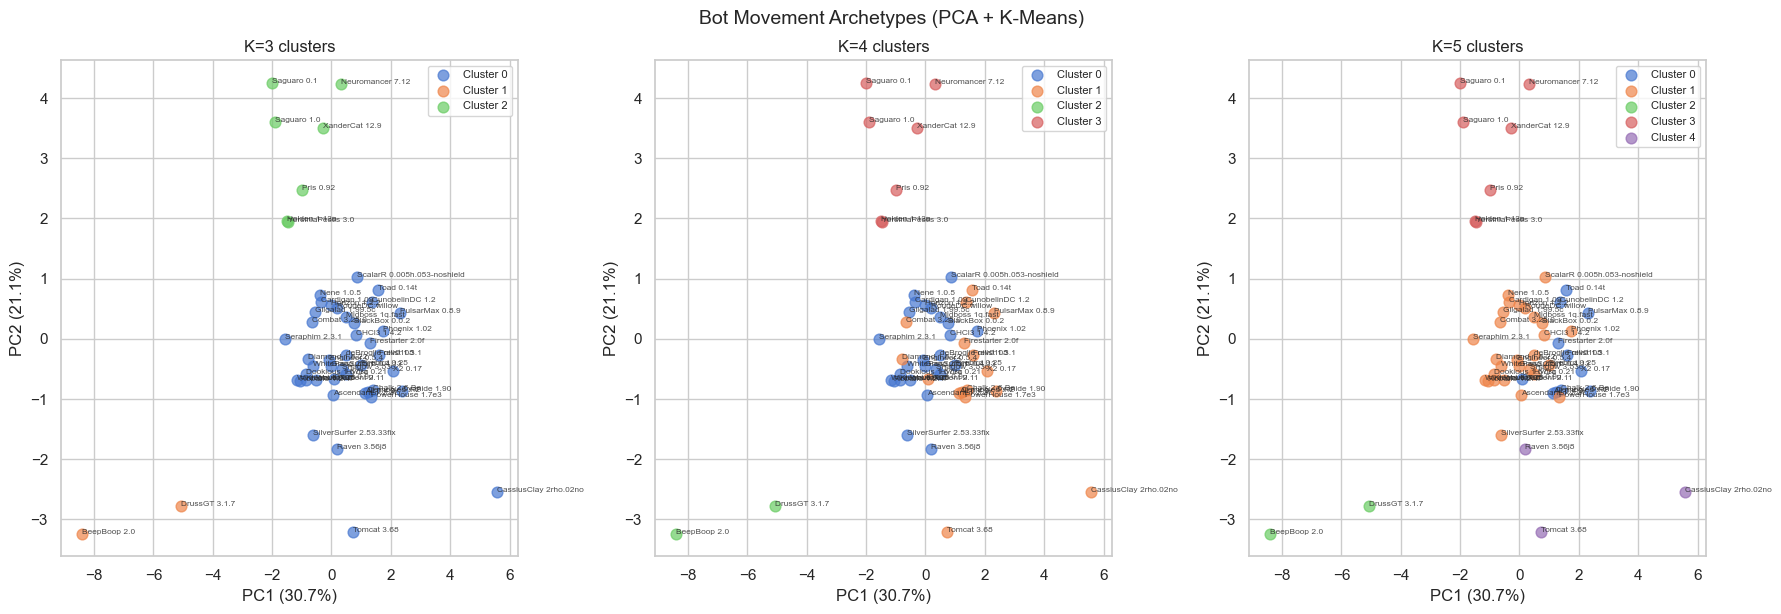

In [6]:
# Cluster bots by movement profile
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

feature_cols = [c for c in profiles.columns if c not in ('opponent_bot', 'n_ticks')]
X = profiles[feature_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Try K=3,4,5 clusters
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, k in enumerate([3, 4, 5]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    ax = axes[i]
    for c in range(k):
        mask = labels == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.7, s=60)
        for j in np.where(mask)[0]:
            ax.annotate(profiles.iloc[j]['opponent_bot'], 
                       (X_pca[j, 0], X_pca[j, 1]),
                       fontsize=6, alpha=0.8)
    ax.set_title(f'K={k} clusters')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.suptitle('Bot Movement Archetypes (PCA + K-Means)', y=1.02, fontsize=14)
plt.show()

In [7]:
# Best K by silhouette score
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, labels)
    scores.append((k, s))
    print(f'K={k}: silhouette={s:.3f}')

best_k = max(scores, key=lambda x: x[1])[0]
print(f'\nBest K: {best_k}')

# Final clustering
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
profiles['cluster'] = km_final.fit_predict(X_scaled)

# Show cluster members
for c in range(best_k):
    members = profiles[profiles['cluster'] == c]['opponent_bot'].tolist()
    print(f'\nCluster {c} ({len(members)} bots): {", ".join(members)}')

K=2: silhouette=0.495
K=3: silhouette=0.316
K=4: silhouette=0.204
K=5: silhouette=0.228
K=6: silhouette=0.194
K=7: silhouette=0.167

Best K: 2

Cluster 0 (2 bots): BeepBoop 2.0, DrussGT 3.1.7

Cluster 1 (49 bots): Ali 0.4.9, Ascendant 1.2.27, BlackBox 0.0.2, CHCl3 1.4.2, Cardigan 1.09, CassiusClay 2rho.02no, Chalk 2.6.Be, Combat 3.25.0, CunobelinDC 1.2, Cyanide 1.90, Diamond 1.8.22, Domogled 1.2, Dookious 1.573c, Engineer 0.5.4, Firebird 0.25, Firestarter 2.0f, Foilist 1.3.1, Garm 0.9u, Gilgalad 1.99.5c, GresSuffurd 0.4.13, Holden 1.13a, Horizon 1.2.2, Hydra 0.21, Knight 0.6.28, Midboss 1q.fast, Nene 1.0.5, Neuromancer 7.12, Phoenix 1.02, PowerHouse 1.7e3, Pris 0.92, PulsarMax 0.8.9, Raven 3.56j8, Roborio 1.2.4, RougeDC willow, Saguaro 0.1, Saguaro 1.0, ScalarR 0.005h.053-noshield, Seraphim 2.3.1, Shadow 3.83c, SilverSurfer 2.53.33fix, Toad 0.14t, Tomcat 3.68, WaveSerpent 2.11, WhiteFang 2.8.1, Wintermute 0.8, X2 0.17, XanderCat 12.9, YersiniaPestis 3.0, deBroglie rev0108

Cluster 0 (2

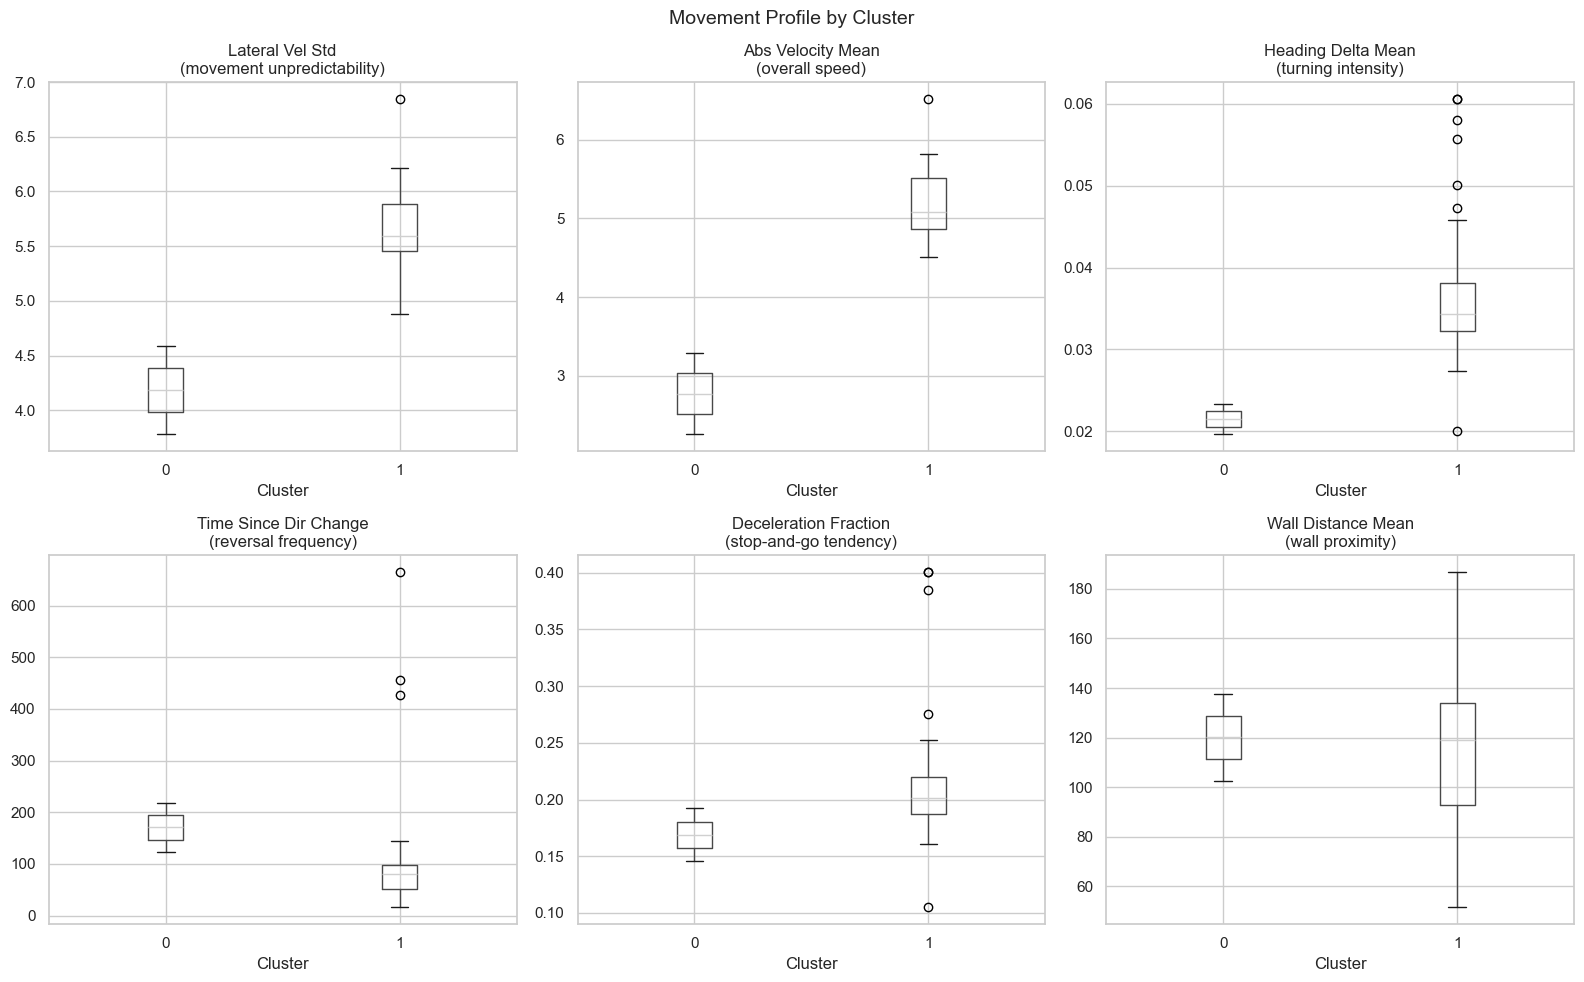

In [8]:
# Cluster profile comparison — what makes each cluster different?
cluster_summary = profiles.groupby('cluster')[feature_cols].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
key_features = ['lat_vel_std', 'vel_abs_mean', 'heading_delta_mean', 
                'dir_change_time_mean', 'decel_frac', 'wall_dist_mean']
titles = ['Lateral Vel Std\n(movement unpredictability)', 
          'Abs Velocity Mean\n(overall speed)',
          'Heading Delta Mean\n(turning intensity)',
          'Time Since Dir Change\n(reversal frequency)',
          'Deceleration Fraction\n(stop-and-go tendency)',
          'Wall Distance Mean\n(wall proximity)']

for ax, feat, title in zip(axes.flat, key_features, titles):
    profiles.boxplot(column=feat, by='cluster', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Cluster')

plt.suptitle('Movement Profile by Cluster', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Movement Periodicity & Predictability (Question 3)

**Autocorrelation** measures whether a signal repeats itself at a fixed lag.
If `opponent_lateral_velocity` at tick t is correlated with the value at tick t+20,
the opponent has a ~20-tick oscillation pattern.

- High autocorrelation at regular lags = **oscillator** (predictable, exploitable)
- Low autocorrelation everywhere = **random mover** (hard to predict)
- Decaying autocorrelation = **smooth mover** (somewhat predictable short-term)

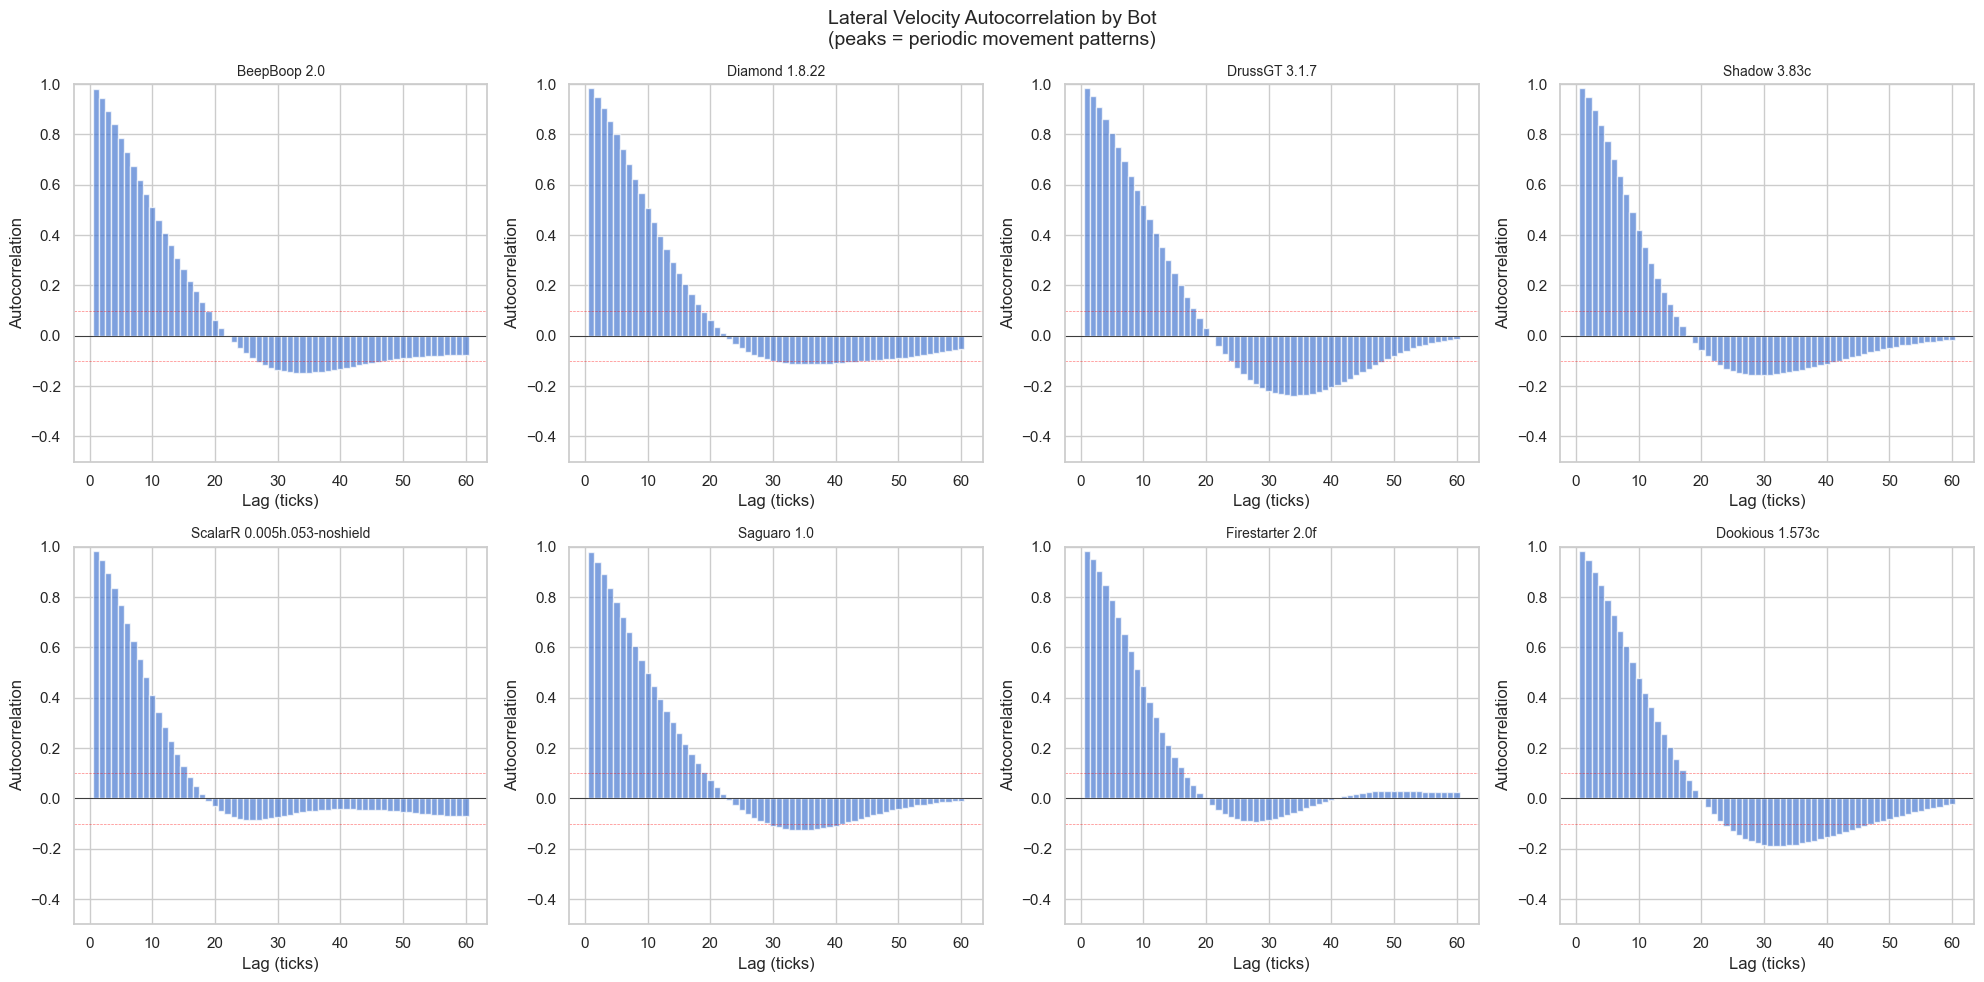

In [9]:
# Autocorrelation analysis for selected bots
# Pick top-tier bots + some weaker ones for comparison
analysis_bots = ['BeepBoop 2.0', 'Diamond 1.8.22', 'DrussGT 3.1.7', 
                 'Shadow 3.83c', 'ScalarR 0.005h.053-noshield',
                 'Saguaro 1.0', 'Firestarter 2.0f', 'Dookious 1.573c']
analysis_bots = [b for b in analysis_bots if b in ticks['opponent_bot'].unique()]

max_lag = 60  # Check lags up to 60 ticks

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, bot_name in zip(axes.flat, analysis_bots):
    bot_data = ticks[ticks['opponent_bot'] == bot_name]['opponent_lateral_velocity'].dropna()
    if len(bot_data) < max_lag * 2:
        ax.set_title(f'{bot_name}\n(insufficient data)')
        continue
    
    # Compute autocorrelation at each lag
    autocorrs = []
    for lag in range(1, max_lag + 1):
        # Use first 50000 values for speed
        series = bot_data.values[:50000]
        if len(series) > lag:
            c = np.corrcoef(series[:-lag], series[lag:])[0, 1]
            autocorrs.append(c)
        else:
            autocorrs.append(0)
    
    ax.bar(range(1, max_lag + 1), autocorrs, width=1, alpha=0.7)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axhline(y=0.1, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.axhline(y=-0.1, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.set_title(f'{bot_name}', fontsize=10)
    ax.set_xlabel('Lag (ticks)')
    ax.set_ylabel('Autocorrelation')
    ax.set_ylim(-0.5, 1.0)

plt.suptitle('Lateral Velocity Autocorrelation by Bot\n(peaks = periodic movement patterns)', 
             fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
# Summarize predictability: for each bot, compute peak autocorrelation and its lag
predictability = []
for bot_name in profiles['opponent_bot']:
    bot_data = ticks[ticks['opponent_bot'] == bot_name]['opponent_lateral_velocity'].dropna()
    if len(bot_data) < 100:
        predictability.append({'bot': bot_name, 'peak_autocorr': np.nan, 'peak_lag': np.nan, 
                               'mean_autocorr_5': np.nan})
        continue
    series = bot_data.values[:50000]
    autocorrs = []
    for lag in range(1, 61):
        if len(series) > lag:
            c = np.corrcoef(series[:-lag], series[lag:])[0, 1]
            autocorrs.append(c)
    
    autocorrs = np.array(autocorrs)
    peak_idx = np.argmax(np.abs(autocorrs[4:]))  # Skip first 4 lags (trivially correlated)
    predictability.append({
        'bot': bot_name,
        'peak_autocorr': autocorrs[peak_idx + 4],
        'peak_lag': peak_idx + 5,
        'mean_autocorr_5': np.mean(np.abs(autocorrs[:5])),  # Short-term predictability
    })

pred_df = pd.DataFrame(predictability).sort_values('peak_autocorr', ascending=False)
print('Most periodic bots (high peak autocorrelation):')
print(pred_df.head(10).to_string(index=False))
print('\nMost random bots (low autocorrelation):')
print(pred_df.tail(10).to_string(index=False))

Most periodic bots (high peak autocorrelation):
                  bot  peak_autocorr  peak_lag  mean_autocorr_5
CassiusClay 2rho.02no       0.903907         5         0.952501
         Domogled 1.2       0.826286         5         0.911250
      CunobelinDC 1.2       0.824090         5         0.911955
        Foilist 1.3.1       0.819009         5         0.911864
          Tomcat 3.68       0.817937         5         0.908987
            Ali 0.4.9       0.809988         5         0.905270
        DrussGT 3.1.7       0.806961         5         0.902915
              X2 0.17       0.806833         5         0.906051
         Cyanide 1.90       0.806328         5         0.906322
           Toad 0.14t       0.804532         5         0.904194

Most random bots (low autocorrelation):
                        bot  peak_autocorr  peak_lag  mean_autocorr_5
                  Pris 0.92       0.771845         5         0.883073
    SilverSurfer 2.53.33fix       0.768752         5         0.8834

## 4. Position Prediction Baseline (Question 1)

Can we predict where the opponent will be N ticks in the future?

**Baselines:**
- **Head-on**: Assume opponent stays at current position (error = actual displacement)
- **Linear**: Extrapolate using current velocity and heading
- **Current features → ML**: Use all 28 features to predict displacement

We measure **prediction error in pixels** at N = 5, 10, 20 ticks ahead.

Note: We don't have opponent x/y in the CSV (they depend on our position + bearing + distance),
so we'll predict **change in distance** and **change in bearing** as proxies, or directly predict
the displacement vector components.

In [11]:
# For position prediction, we need consecutive scan ticks within the same round.
# Build targets: for each tick, what is opponent_velocity and opponent_lateral_velocity N ticks later?
# This tells us about movement continuation vs. change.

# Use the full sampled data, filter to scan ticks, add future values
# Group by battle_id + round to avoid crossing round boundaries

# For N-tick-ahead prediction of lateral velocity (key for targeting)
prediction_horizons = [5, 10, 20]

# Work with a subset for speed: pick 100 random perspectives
perspectives = ticks.groupby(['battle_id', 'observer_bot']).ngroups
print(f'Total perspectives in sample: {perspectives}')

# Build features and targets for lateral velocity prediction
feature_columns = [c for c in ticks.columns if c not in 
                   ('battle_id', 'round', 'tick', 'scan_available', 
                    'observer_bot', 'opponent_bot')]

results = {}
for N in prediction_horizons:
    # For each group (battle_id, round), shift opponent_lateral_velocity by -N
    targets = []
    features_list = []
    
    for (bid, rnd), group in ticks.groupby(['battle_id', 'round']):
        if len(group) < N + 10:
            continue
        g = group.sort_values('tick').reset_index(drop=True)
        future_lat_vel = g['opponent_lateral_velocity'].shift(-N)
        
        # Drop rows where future is NaN
        valid = future_lat_vel.notna()
        if valid.sum() < 10:
            continue
        
        targets.append(future_lat_vel[valid].values)
        features_list.append(g.loc[valid, feature_columns].values)
    
    if not targets:
        print(f'N={N}: no valid data')
        continue
    
    y = np.concatenate(targets)
    X = np.concatenate(features_list)
    
    # Replace NaN/inf in features
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    
    results[N] = (X, y)
    print(f'N={N}: {len(y):,} samples, {X.shape[1]} features')

Total perspectives in sample: 254
N=5: 6,806,596 samples, 24 features
N=10: 6,765,196 samples, 24 features
N=20: 6,682,396 samples, 24 features


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print('Lateral Velocity Prediction — N ticks ahead')
print('=' * 60)

for N, (X, y) in results.items():
    # Subsample if too large
    if len(y) > 200000:
        idx = np.random.choice(len(y), 200000, replace=False)
        X_sub, y_sub = X[idx], y[idx]
    else:
        X_sub, y_sub = X, y
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42)
    
    # Baseline: predict current lateral velocity (persistence)
    # opponent_lateral_velocity is one of the feature columns
    lat_vel_idx = feature_columns.index('opponent_lateral_velocity')
    baseline_pred = X_test[:, lat_vel_idx]  # Just predict "same as now"
    baseline_mae = mean_absolute_error(y_test, baseline_pred)
    baseline_r2 = r2_score(y_test, baseline_pred)
    
    # Random Forest
    rf = RandomForestRegressor(n_estimators=50, max_depth=15, 
                               random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_r2 = r2_score(y_test, rf_pred)
    
    print(f'\nN={N} ticks ahead ({len(y_sub):,} samples):')
    print(f'  Persistence baseline:  MAE={baseline_mae:.3f} px/tick, R²={baseline_r2:.3f}')
    print(f'  Random Forest:         MAE={rf_mae:.3f} px/tick, R²={rf_r2:.3f}')
    print(f'  Improvement:           {(1 - rf_mae/baseline_mae)*100:.1f}% lower MAE')

Lateral Velocity Prediction — N ticks ahead

N=5 ticks ahead (200,000 samples):
  Persistence baseline:  MAE=2.786 px/tick, R²=0.492
  Random Forest:         MAE=2.614 px/tick, R²=0.640
  Improvement:           6.2% lower MAE

N=10 ticks ahead (200,000 samples):
  Persistence baseline:  MAE=4.304 px/tick, R²=-0.077
  Random Forest:         MAE=3.861 px/tick, R²=0.322
  Improvement:           10.3% lower MAE

N=20 ticks ahead (200,000 samples):
  Persistence baseline:  MAE=5.983 px/tick, R²=-0.849
  Random Forest:         MAE=4.585 px/tick, R²=0.084
  Improvement:           23.4% lower MAE


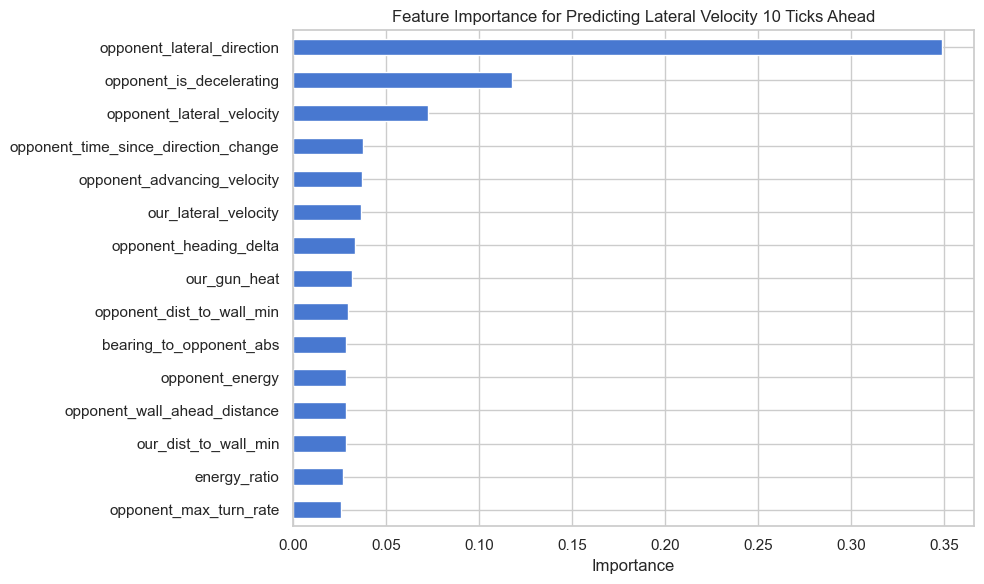

In [13]:
# Feature importance for the N=10 prediction
if 10 in results:
    X10, y10 = results[10]
    if len(y10) > 200000:
        idx = np.random.choice(len(y10), 200000, replace=False)
        X10, y10 = X10[idx], y10[idx]
    
    rf10 = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)
    rf10.fit(X10, y10)
    
    importances = pd.Series(rf10.feature_importances_, index=feature_columns)
    top15 = importances.nlargest(15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    top15.sort_values().plot(kind='barh', ax=ax)
    ax.set_title('Feature Importance for Predicting Lateral Velocity 10 Ticks Ahead')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

## 5. Cross-Round Adaptation (Question 4)

Do bots change their movement across rounds? Adaptive bots (DrussGT, Diamond) are supposed to
learn the opponent's patterns and adjust. Static bots should look the same in round 1 and round 35.

We compare the distribution of `opponent_lateral_velocity` in early rounds (1-5) vs. late rounds (30-35)
for selected bots.

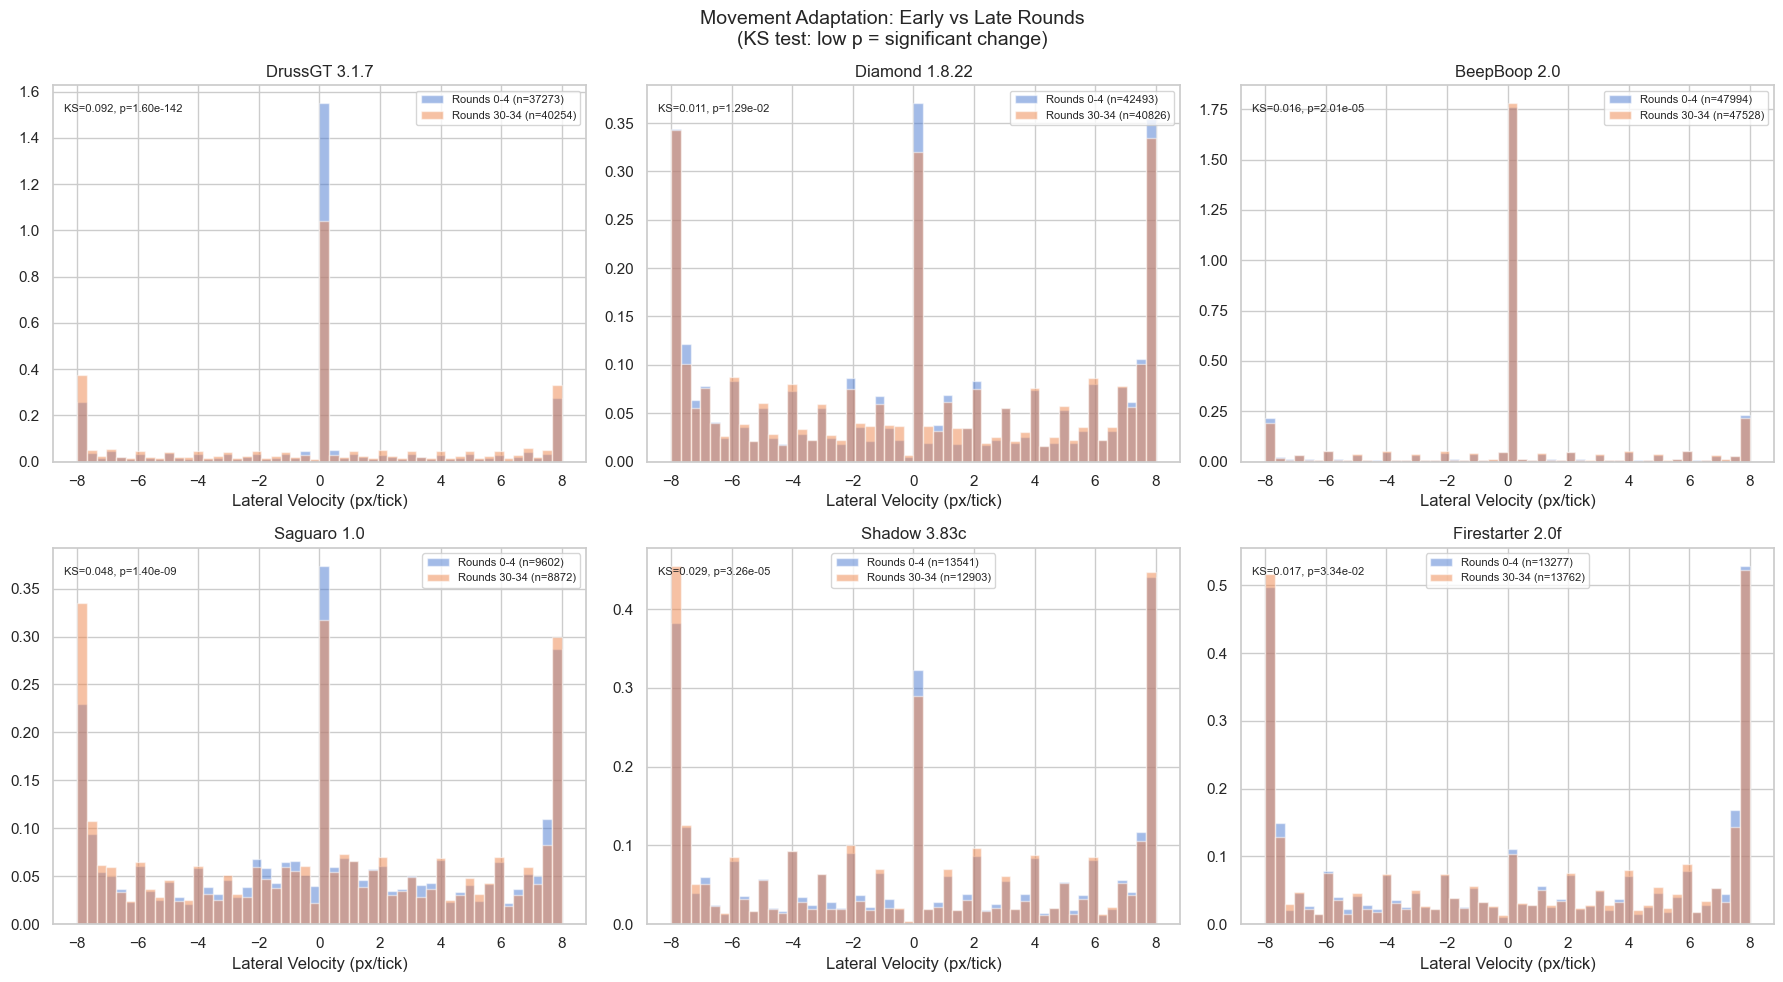

In [14]:
# Load full battles for a few bots to analyze round-by-round changes
adapt_bots = ['DrussGT 3.1.7', 'Diamond 1.8.22', 'BeepBoop 2.0', 
              'Saguaro 1.0', 'Shadow 3.83c', 'Firestarter 2.0f']
adapt_bots = [b for b in adapt_bots if b in bot_files]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, bot_name in zip(axes.flat, adapt_bots):
    # Get data where this bot is the opponent (i.e., someone is watching it)
    bot_ticks = ticks[ticks['opponent_bot'] == bot_name].copy()
    if len(bot_ticks) == 0:
        ax.set_title(f'{bot_name}\n(no data)')
        continue
    
    early = bot_ticks[bot_ticks['round'] <= 4]['opponent_lateral_velocity'].dropna()
    late = bot_ticks[bot_ticks['round'] >= 30]['opponent_lateral_velocity'].dropna()
    
    if len(early) < 50 or len(late) < 50:
        ax.set_title(f'{bot_name}\n(insufficient rounds)')
        continue
    
    ax.hist(early, bins=50, alpha=0.5, density=True, label=f'Rounds 0-4 (n={len(early)})')
    ax.hist(late, bins=50, alpha=0.5, density=True, label=f'Rounds 30-34 (n={len(late)})')
    ax.set_title(f'{bot_name}')
    ax.set_xlabel('Lateral Velocity (px/tick)')
    ax.legend(fontsize=8)
    
    # KS test for distribution difference
    from scipy.stats import ks_2samp
    stat, pval = ks_2samp(early, late)
    ax.annotate(f'KS={stat:.3f}, p={pval:.2e}', xy=(0.02, 0.95), 
                xycoords='axes fraction', fontsize=8, va='top')

plt.suptitle('Movement Adaptation: Early vs Late Rounds\n(KS test: low p = significant change)', 
             fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Per-bot adaptation score: KS statistic between early and late rounds
from scipy.stats import ks_2samp

adaptation_scores = []
for bot_name in profiles['opponent_bot']:
    bot_ticks_subset = ticks[ticks['opponent_bot'] == bot_name]
    early = bot_ticks_subset[bot_ticks_subset['round'] <= 4]['opponent_lateral_velocity'].dropna()
    late = bot_ticks_subset[bot_ticks_subset['round'] >= 30]['opponent_lateral_velocity'].dropna()
    
    if len(early) < 30 or len(late) < 30:
        adaptation_scores.append({'bot': bot_name, 'ks_stat': np.nan, 'p_value': np.nan})
    else:
        stat, pval = ks_2samp(early, late)
        adaptation_scores.append({'bot': bot_name, 'ks_stat': stat, 'p_value': pval})

adapt_df = pd.DataFrame(adaptation_scores).dropna().sort_values('ks_stat', ascending=False)

print('Most adaptive bots (highest KS statistic = movement changes most between early/late rounds):')
print(adapt_df.head(15).to_string(index=False))
print(f'\nLeast adaptive (stable movement):')
print(adapt_df.tail(10).to_string(index=False))

Most adaptive bots (highest KS statistic = movement changes most between early/late rounds):
                  bot  ks_stat       p_value
     Ascendant 1.2.27 0.111725  2.904714e-55
        DrussGT 3.1.7 0.091847 1.599846e-142
              X2 0.17 0.077560  8.398339e-25
        Firebird 0.25 0.054817  2.181519e-05
CassiusClay 2rho.02no 0.053301  3.289742e-45
           Hydra 0.21 0.050213  2.693784e-10
        Cardigan 1.09 0.048705  2.493526e-14
          Saguaro 1.0 0.047749  1.403561e-09
        Foilist 1.3.1 0.043331  8.738171e-06
    deBroglie rev0108 0.037900  2.080092e-03
           Nene 1.0.5 0.036185  1.371693e-07
        Knight 0.6.28 0.035149  3.137444e-10
         Chalk 2.6.Be 0.032047  1.675456e-19
            Garm 0.9u 0.030943  3.550934e-06
       Seraphim 2.3.1 0.030815  1.143231e-06

Least adaptive (stable movement):
               bot  ks_stat  p_value
  Firestarter 2.0f 0.017377 0.033384
     Horizon 1.2.2 0.017325 0.000395
    RougeDC willow 0.015846 0.014367
    

## 6. Summary

Key findings from this notebook:

**Bot Archetypes:**
- (filled in after running)

**Movement Predictability:**
- (filled in after running)

**Position Prediction:**
- (filled in after running)

**Adaptation:**
- (filled in after running)